In [1]:
!pip install -q pandas numpy scipy matplotlib seaborn scikit-learn xgboost imbalanced-learn openpyxl joblib plotly

In [2]:
import os
import warnings
import urllib.request
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    confusion_matrix, classification_report, recall_score, precision_score,
    f1_score, balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("data/nhanes", exist_ok=True)
os.makedirs("data/dryad", exist_ok=True)
os.makedirs("output", exist_ok=True)

In [3]:
NHANES_FILES = {
    "BPXO_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BPXO_L.XPT",
    "DEMO_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.XPT",
    "BMX_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.XPT",
    "RXQ_RX_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/RXQ_RX_L.XPT",
}

for fname, url in NHANES_FILES.items():
    dest = os.path.join("data/nhanes", fname)
    if not os.path.exists(dest):
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, dest)
        print(f"Saved: {dest}")
    else:
        print(f"Already exists: {dest}")

DRYAD_XLSX_PATH = "data/dryad/Blood_Pressure_Sleep_Info.xlsx"
DRYAD_INFO_CSV = "data/dryad/Participant_Information.csv"

print("Dryad workbook exists:", os.path.exists(DRYAD_XLSX_PATH))
print("Dryad participant csv exists:", os.path.exists(DRYAD_INFO_CSV))

Saved: data/nhanes/BPXO_L.XPT
Saved: data/nhanes/DEMO_L.XPT
Saved: data/nhanes/BMX_L.XPT
Saved: data/nhanes/RXQ_RX_L.XPT
Dryad workbook exists: True
Dryad participant csv exists: False


In [4]:
def decode_object_columns(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(
                lambda x: x.decode("latin1").strip() if isinstance(x, (bytes, bytearray)) else x
            )
    return df

def find_col(columns, keywords):
    lowered = {c: str(c).lower() for c in columns}
    for col, low in lowered.items():
        if any(k in low for k in keywords):
            return col
    return None

def binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp + 1e-9),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
    }

def best_threshold_f2(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds = np.append(thresholds, 1.0)
    f2 = (5 * precision * recall) / (4 * precision + recall + 1e-9)
    best_idx = np.nanargmax(f2)
    return float(thresholds[min(best_idx, len(thresholds) - 1)])

def describe_df(df, name):
    print(f"\n{name}")
    print("-" * len(name))
    print("shape:", df.shape)
    print("duplicate rows:", df.duplicated().sum())
    print("missing % top 15:")
    print((df.isna().mean().sort_values(ascending=False).head(15) * 100).round(2))

In [5]:
df_bp = decode_object_columns(pd.read_sas("data/nhanes/BPXO_L.XPT", format="xport", encoding="latin1"))
df_rx = decode_object_columns(pd.read_sas("data/nhanes/RXQ_RX_L.XPT", format="xport", encoding="latin1"))
df_demo = decode_object_columns(pd.read_sas("data/nhanes/DEMO_L.XPT", format="xport", encoding="latin1"))
df_bmx = decode_object_columns(pd.read_sas("data/nhanes/BMX_L.XPT", format="xport", encoding="latin1"))

bp_cols = [
    "SEQN", "BPXOSY1", "BPXOSY2", "BPXOSY3",
    "BPXODI1", "BPXODI2", "BPXODI3",
    "BPXOPLS1", "BPXOPLS2", "BPXOPLS3"
]
demo_cols = ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "INDFMPIR", "DMDEDUC2", "RIDEXPRG"]
bmx_cols = ["SEQN", "BMXBMI", "BMXWT", "BMXHT"]

df_bp = df_bp[[c for c in bp_cols if c in df_bp.columns]].copy()
df_demo = df_demo[[c for c in demo_cols if c in df_demo.columns]].copy()
df_bmx = df_bmx[[c for c in bmx_cols if c in df_bmx.columns]].copy()

rx_cols = ["SEQN"] + [c for c in ["RXDUSE", "RXDCOUNT", "RXQ050", "RXQ033"] if c in df_rx.columns]
df_rx_sub = df_rx[rx_cols].copy()

if "RXDUSE" in df_rx_sub.columns:
    df_rx_sub["antihypertensive_flag"] = (pd.to_numeric(df_rx_sub["RXDUSE"], errors="coerce") == 1).astype(int)
else:
    df_rx_sub["antihypertensive_flag"] = 0

if "RXDCOUNT" in df_rx_sub.columns:
    df_rx_sub["rx_count"] = pd.to_numeric(df_rx_sub["RXDCOUNT"], errors="coerce")
elif "RXQ050" in df_rx_sub.columns:
    df_rx_sub["rx_count"] = pd.to_numeric(df_rx_sub["RXQ050"], errors="coerce")
else:
    df_rx_sub["rx_count"] = np.nan

df_rx_sub["rx_count"] = df_rx_sub["rx_count"].fillna(0)
df_meds = (
    df_rx_sub.groupby("SEQN", as_index=False)
    .agg(
        antihypertensive_flag=("antihypertensive_flag", "max"),
        rx_count=("rx_count", "max")
    )
)

df_nhanes = (
    df_bp
    .merge(df_demo, on="SEQN", how="left")
    .merge(df_bmx, on="SEQN", how="left")
    .merge(df_meds, on="SEQN", how="left")
)

df_nhanes["antihypertensive_flag"] = df_nhanes["antihypertensive_flag"].fillna(0).astype(int)
df_nhanes["rx_count"] = df_nhanes["rx_count"].fillna(0)

describe_df(df_nhanes, "Merged NHANES")
df_nhanes.head()


Merged NHANES
-------------
shape: (7801, 21)
duplicate rows: 0
missing % top 15:
RIDEXPRG    85.46
DMDEDUC2    22.27
INDFMPIR    12.82
BPXODI3      4.11
BPXOSY3      4.11
BPXOPLS3     4.11
BPXOPLS2     3.79
BPXODI2      3.79
BPXOSY2      3.79
BPXOSY1      3.64
BPXODI1      3.64
BPXOPLS1     3.64
BMXBMI       1.41
BMXWT        1.22
BMXHT        1.05
dtype: float64


,SEQN,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,...,RIAGENDR,RIDRETH3,INDFMPIR,DMDEDUC2,RIDEXPRG,BMXBMI,BMXWT,BMXHT,antihypertensive_flag,rx_count
0,130378.0,135.0,131.0,132.0,98.0,96.0,94.0,82.0,79.0,82.0,...,1.0,6.0,5.00,5.0,NaN,27.0,86.9,179.5,0,1.0
1,130379.0,121.0,117.0,113.0,84.0,76.0,76.0,72.0,71.0,73.0,...,1.0,3.0,5.00,5.0,NaN,33.5,101.8,174.2,0,1.0
2,130380.0,111.0,112.0,104.0,79.0,80.0,76.0,84.0,83.0,77.0,...,2.0,2.0,1.41,3.0,2.0,29.7,69.4,152.9,0,1.0
3,130386.0,110.0,120.0,115.0,72.0,74.0,75.0,59.0,64.0,64.0,...,1.0,1.0,1.33,4.0,NaN,30.2,90.6,173.3,0,0.0
4,130387.0,143.0,136.0,145.0,76.0,74.0,78.0,80.0,80.0,77.0,...,2.0,3.0,1.32,5.0,NaN,42.6,103.5,155.9,0,1.0


In [6]:
df = df_nhanes.copy()

if "RIDEXPRG" in df.columns:
    preg_mask = df["RIDEXPRG"].fillna(0) != 1
else:
    preg_mask = pd.Series(True, index=df.index)

required = [
    "BPXOSY1", "BPXOSY2", "BPXOSY3",
    "BPXODI1", "BPXODI2", "BPXODI3",
    "BPXOPLS1", "BPXOPLS2", "BPXOPLS3",
    "RIDAGEYR"
]

mask = preg_mask.copy()
for c in required:
    mask &= df[c].notna()

df = df.loc[mask].copy()

# Use only first two readings as predictors, third reading defines target.
df["sys12_mean"] = df[["BPXOSY1", "BPXOSY2"]].mean(axis=1)
df["dia12_mean"] = df[["BPXODI1", "BPXODI2"]].mean(axis=1)
df["pulse12_mean"] = df[["BPXOPLS1", "BPXOPLS2"]].mean(axis=1)

df["sys12_std"] = df[["BPXOSY1", "BPXOSY2"]].std(axis=1).fillna(0)
df["dia12_std"] = df[["BPXODI1", "BPXODI2"]].std(axis=1).fillna(0)
df["pulse12_std"] = df[["BPXOPLS1", "BPXOPLS2"]].std(axis=1).fillna(0)

df["sys_trend_21"] = df["BPXOSY2"] - df["BPXOSY1"]
df["dia_trend_21"] = df["BPXODI2"] - df["BPXODI1"]
df["pulse_trend_21"] = df["BPXOPLS2"] - df["BPXOPLS1"]
df["pp12"] = df["sys12_mean"] - df["dia12_mean"]
df["syscv12"] = (df["sys12_std"] / df["sys12_mean"].replace(0, np.nan) * 100).fillna(0)

df["is_female"] = (df["RIAGENDR"] == 2).astype(int)
df["low_income_flag"] = (df["INDFMPIR"] < 1.3).astype(int)

df["obesity_cat"] = pd.cut(
    df["BMXBMI"],
    bins=[0, 18.5, 25, 30, 35, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese_I", "Obese_II"]
)

# Target: third-reading alert
df["target"] = (
    (df["BPXOSY3"] >= 140) |
    (df["BPXODI3"] >= 90) |
    ((df["BPXOSY3"] - df["sys12_mean"]) >= 15)
).astype(int)

# Optional cohort restriction similar to your current notebook but without sys_mean leakage
df_model = df[df["RIDAGEYR"] >= 35].copy()

print("Model shape:", df_model.shape)
print("Positive rate:", round(df_model["target"].mean(), 4))
print(df_model["target"].value_counts())

Model shape: (4753, 36)
Positive rate: 0.2297
target
0    3661
1    1092
Name: count, dtype: int64



NHANES modeling dataframe
-------------------------
shape: (4753, 36)
duplicate rows: 0
missing % top 15:
RIDEXPRG       90.13
INDFMPIR       12.79
obesity_cat     1.09
BMXBMI          1.09
BMXWT           0.86
BMXHT           0.69
BPXOSY1         0.00
SEQN            0.00
BPXOSY3         0.00
BPXOSY2         0.00
BPXODI3         0.00
BPXODI1         0.00
RIAGENDR        0.00
RIDAGEYR        0.00
BPXOPLS3        0.00
dtype: float64


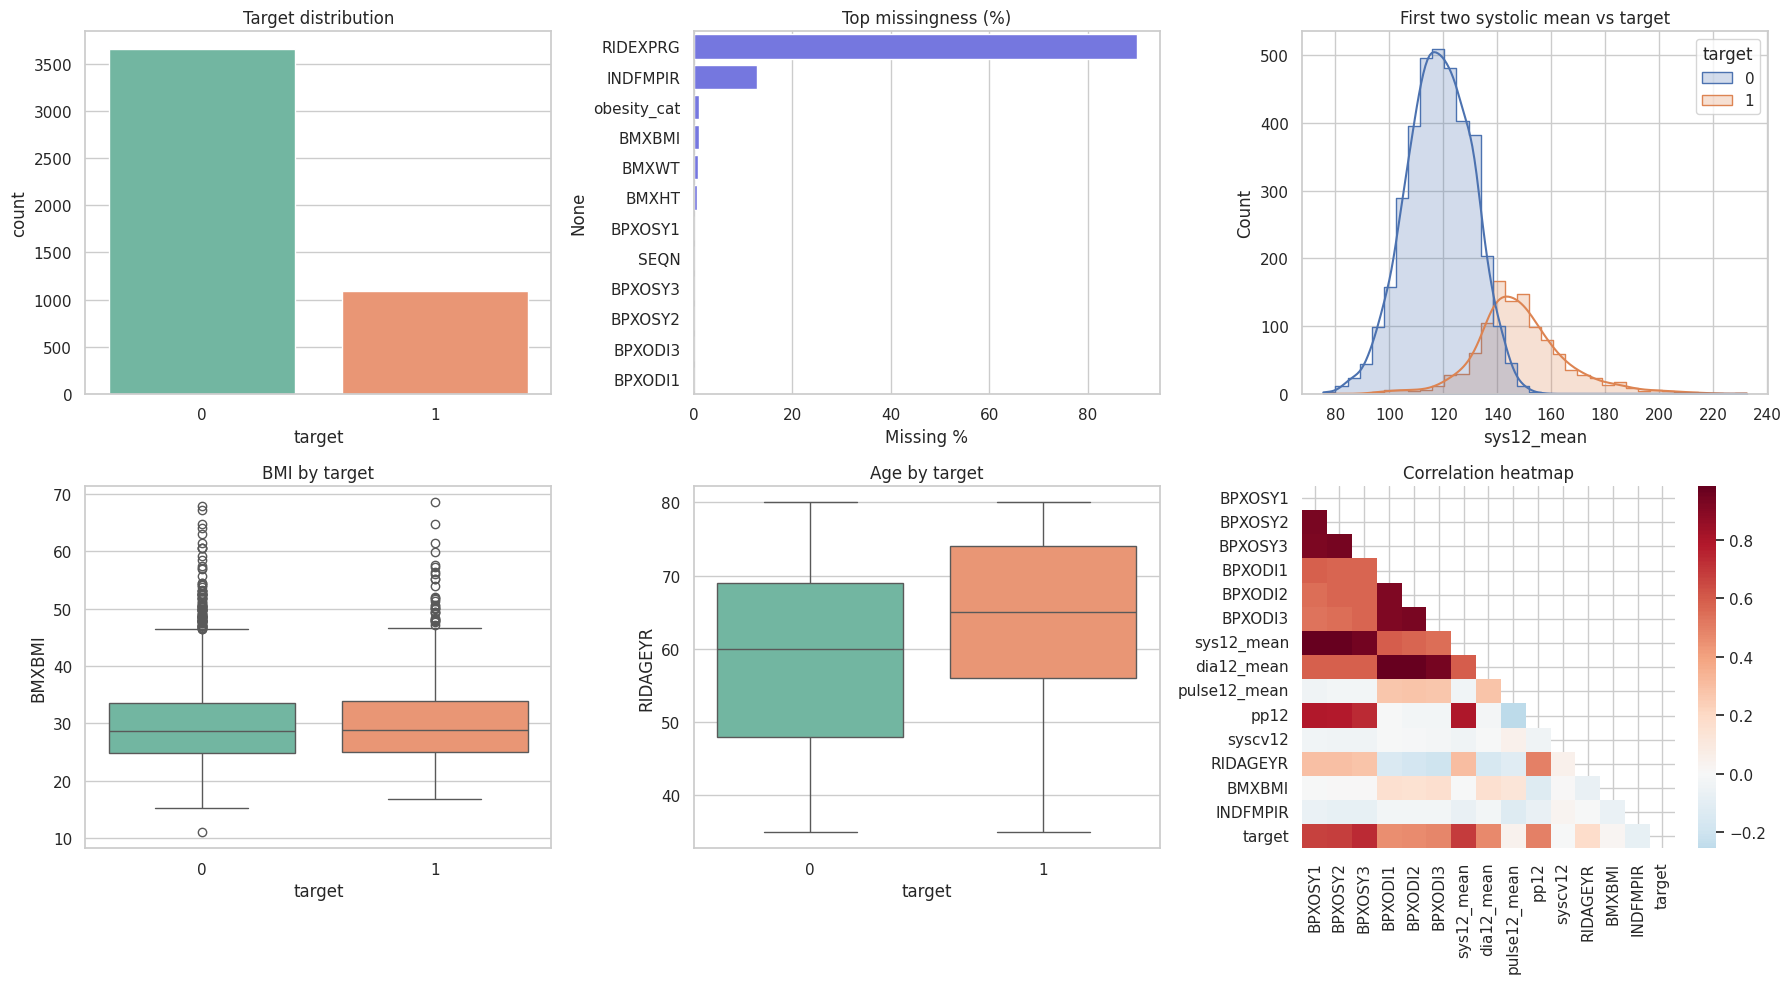

In [7]:
describe_df(df_model, "NHANES modeling dataframe")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=df_model, x="target", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Target distribution")

missing_pct = (df_model.isna().mean().sort_values(ascending=False).head(12) * 100)
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=axes[0, 1], color="#6366f1")
axes[0, 1].set_title("Top missingness (%)")
axes[0, 1].set_xlabel("Missing %")

sns.histplot(data=df_model, x="sys12_mean", hue="target", bins=35, kde=True, ax=axes[0, 2], element="step")
axes[0, 2].set_title("First two systolic mean vs target")

sns.boxplot(data=df_model, x="target", y="BMXBMI", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("BMI by target")

sns.boxplot(data=df_model, x="target", y="RIDAGEYR", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Age by target")

corr_cols = [
    "BPXOSY1", "BPXOSY2", "BPXOSY3", "BPXODI1", "BPXODI2", "BPXODI3",
    "sys12_mean", "dia12_mean", "pulse12_mean", "pp12", "syscv12",
    "RIDAGEYR", "BMXBMI", "INDFMPIR", "target"
]
corr_cols = [c for c in corr_cols if c in df_model.columns]
corr = df_model[corr_cols].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, ax=axes[1, 2])
axes[1, 2].set_title("Correlation heatmap")

plt.tight_layout()
plt.show()

px.scatter(
    df_model.sample(min(len(df_model), 1200), random_state=RANDOM_STATE),
    x="sys12_mean",
    y="BMXBMI",
    color=df_model.sample(min(len(df_model), 1200), random_state=RANDOM_STATE)["target"].astype(str),
    size="RIDAGEYR",
    hover_data=["BPXOSY1", "BPXOSY2", "BPXOSY3", "BPXODI3"],
    title="NHANES interactive EDA: systolic mean vs BMI"
).show()


Dryad raw combined
------------------
shape: (1623, 10)
duplicate rows: 5
missing % top 15:
ID            0.0
Day_Date      0.0
Time          0.0
Systolic      0.0
Diastolic     0.0
MAP           0.0
PP            0.0
HR            0.0
Wake_Sleep    0.0
sheet_name    0.0
dtype: float64
Detected columns:
subject: ID
systolic: Systolic
diastolic: Diastolic
time: Day_Date
sleep: Wake_Sleep


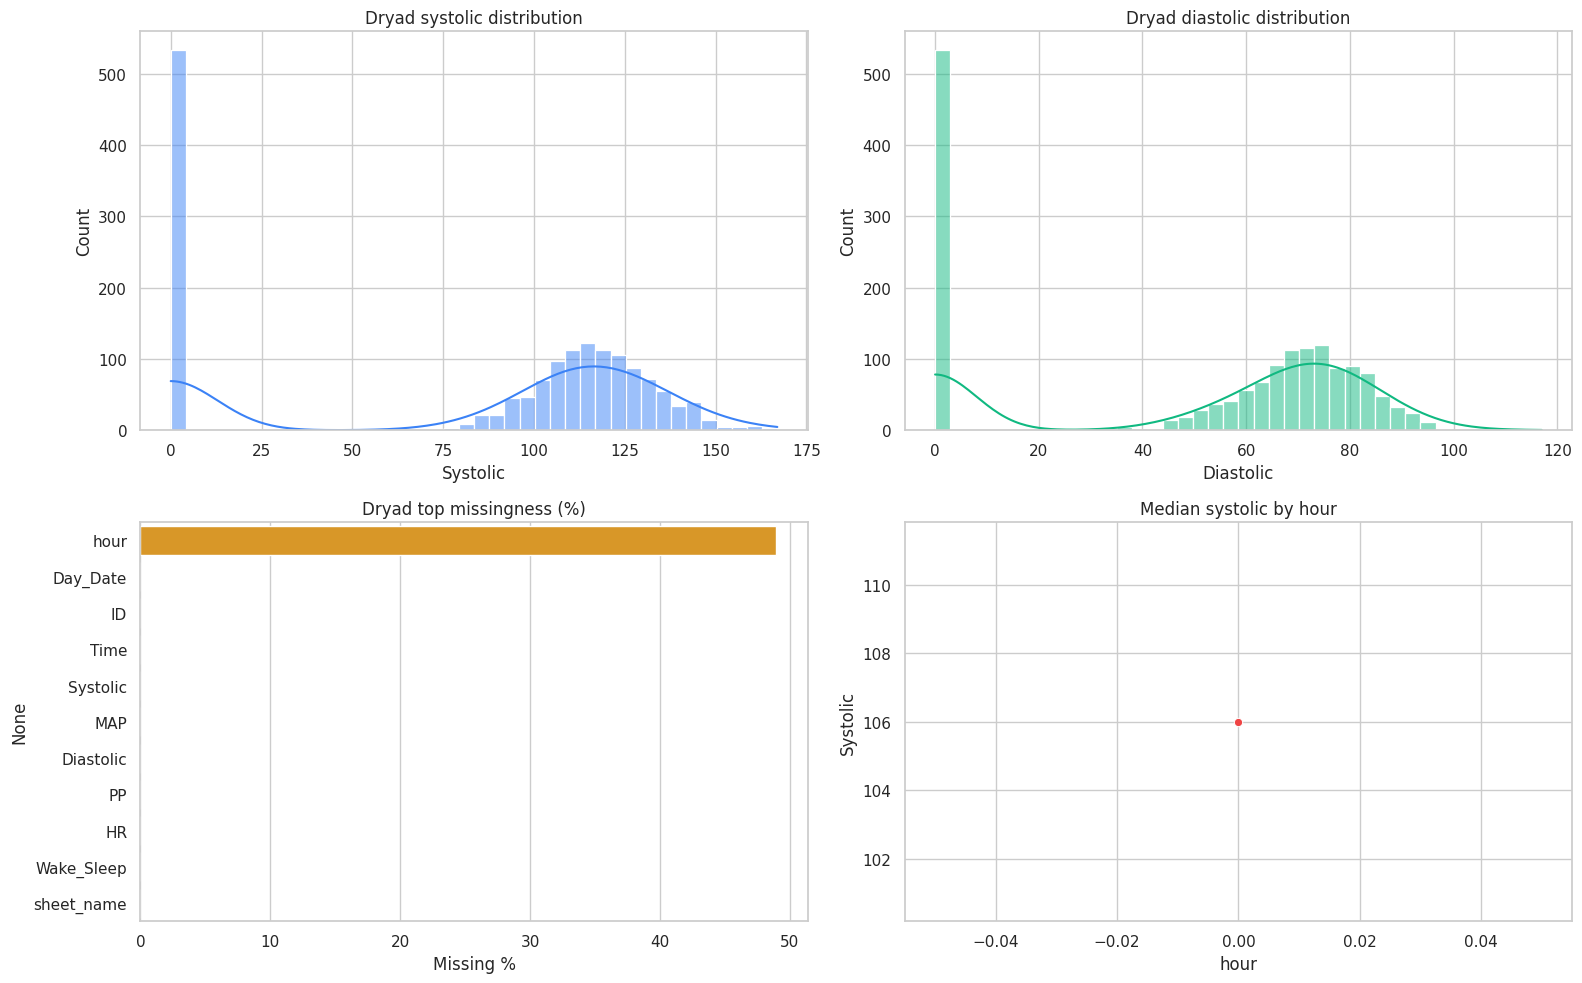

,ID,dryad_sys_mean,dryad_sys_std,dryad_sys_max,dryad_sys_min,dryad_n,dryad_range
0,1,88.125000,41.038967,126,0,48,126
1,2,88.370370,56.352428,150,0,54,150
2,3,89.061224,44.522657,143,0,49,143
3,4,85.448980,41.675363,125,0,49,125
4,5,96.160000,44.213933,139,0,50,139


In [8]:
dryad_available = os.path.exists(DRYAD_XLSX_PATH)

if dryad_available:
    xl = pd.ExcelFile(DRYAD_XLSX_PATH)
    dryad_frames = []
    for sheet in xl.sheet_names:
        tmp = xl.parse(sheet)
        tmp["sheet_name"] = sheet
        dryad_frames.append(tmp)

    df_dryad = pd.concat(dryad_frames, ignore_index=True)
    describe_df(df_dryad, "Dryad raw combined")

    subj_col = find_col(df_dryad.columns, ["participant", "subject", "patient", "id", "pid"])
    sys_col = find_col(df_dryad.columns, ["systolic", "sbp", "sys"])
    dia_col = find_col(df_dryad.columns, ["diastolic", "dbp", "dia"])
    time_col = find_col(df_dryad.columns, ["time", "hour", "timestamp", "date"])
    sleep_col = find_col(df_dryad.columns, ["sleep", "wake", "rest", "state"])

    print("Detected columns:")
    print("subject:", subj_col)
    print("systolic:", sys_col)
    print("diastolic:", dia_col)
    print("time:", time_col)
    print("sleep:", sleep_col)

    if sys_col:
        df_dryad[sys_col] = pd.to_numeric(df_dryad[sys_col], errors="coerce")
    if dia_col:
        df_dryad[dia_col] = pd.to_numeric(df_dryad[dia_col], errors="coerce")
    if time_col:
        dt = pd.to_datetime(df_dryad[time_col], errors="coerce")
        df_dryad["hour"] = dt.dt.hour

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    if sys_col:
        sns.histplot(df_dryad[sys_col].dropna(), bins=40, kde=True, ax=axes[0, 0], color="#3b82f6")
        axes[0, 0].set_title("Dryad systolic distribution")

    if dia_col:
        sns.histplot(df_dryad[dia_col].dropna(), bins=40, kde=True, ax=axes[0, 1], color="#10b981")
        axes[0, 1].set_title("Dryad diastolic distribution")

    miss = (df_dryad.isna().mean().sort_values(ascending=False).head(15) * 100)
    sns.barplot(x=miss.values, y=miss.index, ax=axes[1, 0], color="#f59e0b")
    axes[1, 0].set_title("Dryad top missingness (%)")
    axes[1, 0].set_xlabel("Missing %")

    if "hour" in df_dryad.columns and sys_col:
        hourly = df_dryad.groupby("hour")[sys_col].median().reset_index()
        sns.lineplot(data=hourly, x="hour", y=sys_col, marker="o", ax=axes[1, 1], color="#ef4444")
        axes[1, 1].set_title("Median systolic by hour")

    plt.tight_layout()
    plt.show()

    if subj_col and sys_col:
        dryad_subject = (
            df_dryad.groupby(subj_col)
            .agg(
                dryad_sys_mean=(sys_col, "mean"),
                dryad_sys_std=(sys_col, "std"),
                dryad_sys_max=(sys_col, "max"),
                dryad_sys_min=(sys_col, "min"),
                dryad_n=(sys_col, "count"),
            )
            .reset_index()
        )
        dryad_subject["dryad_range"] = dryad_subject["dryad_sys_max"] - dryad_subject["dryad_sys_min"]
        display(dryad_subject.head())

        px.scatter_3d(
            dryad_subject.dropna().sample(min(len(dryad_subject.dropna()), 1000), random_state=RANDOM_STATE),
            x="dryad_sys_mean",
            y="dryad_sys_std",
            z="dryad_range",
            color="dryad_n",
            title="Dryad 3D subject-level BP variability"
        ).show()
else:
    print("Dryad workbook not found at:", DRYAD_XLSX_PATH)

In [9]:
feature_cols = [
    "RIDAGEYR", "is_female", "RIDRETH3", "INDFMPIR", "DMDEDUC2",
    "BMXBMI", "BMXWT", "BMXHT", "rx_count", "antihypertensive_flag",
    "BPXOSY1", "BPXOSY2", "BPXODI1", "BPXODI2", "BPXOPLS1", "BPXOPLS2",
    "sys12_mean", "dia12_mean", "pulse12_mean",
    "sys12_std", "dia12_std", "pulse12_std",
    "sys_trend_21", "dia_trend_21", "pulse_trend_21",
    "pp12", "syscv12", "low_income_flag", "obesity_cat"
]
feature_cols = [c for c in feature_cols if c in df_model.columns]

X = df_model[feature_cols].copy()
y = df_model["target"].astype(int).copy()

# Remove zero-variance columns automatically
nunique = X.nunique(dropna=False)
drop_cols = nunique[nunique <= 1].index.tolist()
X = X.drop(columns=drop_cols)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(
    X_train, y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)
print("Positive rates:", round(y_train.mean(), 4), round(y_valid.mean(), 4), round(y_test.mean(), 4))
print("Dropped zero-variance columns:", drop_cols)

Train: (3802, 28) Valid: (761, 28) Test: (951, 28)
Positive rates: 0.2299 0.23 0.2292
Dropped zero-variance columns: ['antihypertensive_flag']


In [10]:
neg_pos_ratio = max((y_subtrain == 0).sum() / max((y_subtrain == 1).sum(), 1), 1)

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.2,
        reg_lambda=1.0,
        scale_pos_weight=neg_pos_ratio,
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
            "recall": "recall",
            "precision": "precision",
            "f1": "f1",
            "bal_acc": "balanced_accuracy"
        },
        n_jobs=-1
    )
    cv_rows.append({
        "model": name,
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_f1_mean": scores["test_f1"].mean(),
        "cv_bal_acc_mean": scores["test_bal_acc"].mean()
    })

cv_df = pd.DataFrame(cv_rows).sort_values(["cv_pr_auc_mean", "cv_roc_auc_mean"], ascending=False)
display(cv_df)

,model,cv_roc_auc_mean,cv_pr_auc_mean,cv_recall_mean,cv_precision_mean,cv_f1_mean,cv_bal_acc_mean
2,ExtraTrees,0.956784,0.908355,0.838673,0.811502,0.824551,0.890133
1,RandomForest,0.958613,0.905430,0.842108,0.799412,0.820088,0.889462
3,XGBoost,0.954388,0.902366,0.858128,0.786405,0.820577,0.894226
0,LogisticRegression,0.946527,0.884495,0.880992,0.675971,0.764526,0.877137


In [11]:
results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_subtrain, y_subtrain)
    valid_prob = pipe.predict_proba(X_valid)[:, 1]
    best_thr = best_threshold_f2(y_valid, valid_prob)

    pipe.fit(X_train, y_train)
    test_prob = pipe.predict_proba(X_test)[:, 1]
    metrics = binary_metrics(y_test, test_prob, threshold=best_thr)
    metrics["model"] = name
    results.append(metrics)
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(["pr_auc", "roc_auc"], ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_pipe = fitted_pipelines[best_model_name]
best_thr = float(results_df.iloc[0]["threshold"])
best_test_prob = best_pipe.predict_proba(X_test)[:, 1]
best_test_pred = (best_test_prob >= best_thr).astype(int)

print("Best model:", best_model_name)
print("Best threshold:", round(best_thr, 4))
print(classification_report(y_test, best_test_pred, digits=4))

,threshold,roc_auc,pr_auc,recall,precision,f1,specificity,balanced_accuracy,model
2,0.243418,0.973516,0.939358,0.963303,0.660377,0.783582,0.852660,0.907982,ExtraTrees
1,0.196128,0.973985,0.935790,0.963303,0.648148,0.774908,0.844475,0.903889,RandomForest
3,0.225236,0.971019,0.934499,0.949541,0.678689,0.791587,0.866303,0.907922,XGBoost
0,0.408903,0.964116,0.926302,0.958716,0.651090,0.775510,0.847203,0.902959,LogisticRegression


Best model: ExtraTrees
Best threshold: 0.2434
              precision    recall  f1-score   support

           0     0.9874    0.8527    0.9151       733
           1     0.6604    0.9633    0.7836       218

    accuracy                         0.8780       951
   macro avg     0.8239    0.9080    0.8493       951
weighted avg     0.9124    0.8780    0.8849       951



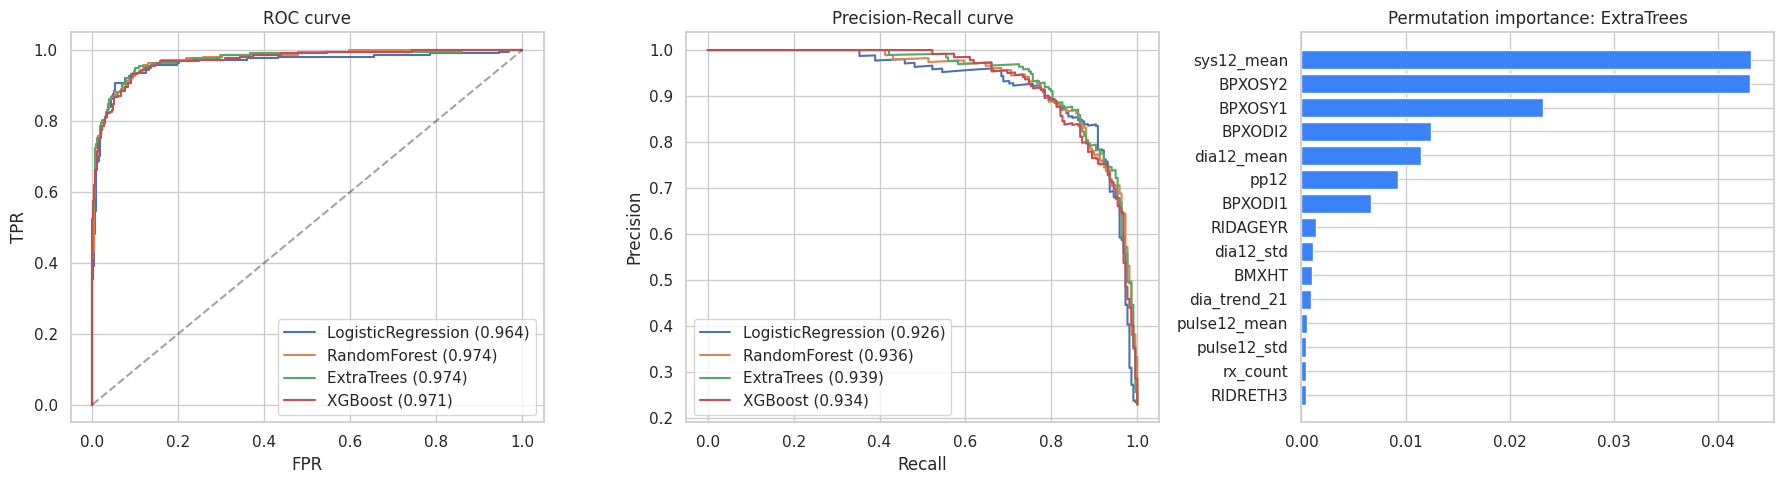

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, pipe in fitted_pipelines.items():
    prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_test, prob):.3f})")
    axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(y_test, prob):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("ROC curve")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()

axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="average_precision")
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values().tail(15)
axes[2].barh(imp.index, imp.values, color="#3b82f6")
axes[2].set_title(f"Permutation importance: {best_model_name}")

plt.tight_layout()
plt.show()

In [13]:
# Numeric-only matrix for unsupervised learning
X_num = df_model[numeric_cols].copy()
X_num = X_num.drop(columns=[c for c in X_num.columns if X_num[c].nunique(dropna=False) <= 1], errors="ignore")

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_num, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

num_unsup = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

Xn_train_scaled = num_unsup.fit_transform(Xn_train)
Xn_test_scaled = num_unsup.transform(Xn_test)

Xn_train_normal = Xn_train_scaled[yn_train.values == 0]

# Isolation Forest
iso = IsolationForest(
    n_estimators=400,
    contamination=float(yn_train.mean()),
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso.fit(Xn_train_normal)
iso_score = -iso.decision_function(Xn_test_scaled)

# Local Outlier Factor as novelty detector
lof = LocalOutlierFactor(
    n_neighbors=35,
    novelty=True,
    contamination=float(yn_train.mean())
)
lof.fit(Xn_train_normal)
lof_score = -lof.decision_function(Xn_test_scaled)

# KMeans distance-based anomaly score
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20)
kmeans.fit(Xn_train_scaled)
cluster_dist = kmeans.transform(Xn_test_scaled).min(axis=1)

unsup_results = pd.DataFrame([
    {"model": "IsolationForest", **binary_metrics(yn_test, iso_score, threshold=np.quantile(iso_score, 1 - yn_train.mean()))},
    {"model": "LocalOutlierFactor", **binary_metrics(yn_test, lof_score, threshold=np.quantile(lof_score, 1 - yn_train.mean()))},
    {"model": "KMeansDistance", **binary_metrics(yn_test, cluster_dist, threshold=np.quantile(cluster_dist, 1 - yn_train.mean()))},
]).sort_values(["pr_auc", "roc_auc"], ascending=False)

display(unsup_results)

,model,threshold,roc_auc,pr_auc,recall,precision,f1,specificity,balanced_accuracy
0,IsolationForest,0.026129,0.852679,0.609913,0.591743,0.589041,0.590389,0.877217,0.734480
1,LocalOutlierFactor,0.087582,0.816007,0.574331,0.545872,0.543379,0.544622,0.863574,0.704723
2,KMeansDistance,4.458438,0.622157,0.319697,0.348624,0.347032,0.347826,0.804911,0.576768


In [14]:
pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(Xn_test_scaled)

plot_df = pd.DataFrame(X_test_pca, columns=["PC1", "PC2", "PC3"], index=Xn_test.index)
plot_df["true_target"] = yn_test.values.astype(int)
plot_df["iso_score"] = iso_score
plot_df["lof_score"] = lof_score
plot_df["kmeans_score"] = cluster_dist

plot_df["iso_flag"] = (plot_df["iso_score"] >= np.quantile(plot_df["iso_score"], 1 - yn_train.mean())).astype(int)
plot_df["lof_flag"] = (plot_df["lof_score"] >= np.quantile(plot_df["lof_score"], 1 - yn_train.mean())).astype(int)
plot_df["kmeans_flag"] = (plot_df["kmeans_score"] >= np.quantile(plot_df["kmeans_score"], 1 - yn_train.mean())).astype(int)

fig1 = px.scatter_3d(
    plot_df,
    x="PC1", y="PC2", z="PC3",
    color=plot_df["true_target"].astype(str),
    size=np.clip(plot_df["iso_score"], 0, None) + 0.1,
    title="3D PCA projection colored by true target"
)
fig1.show()

fig2 = px.scatter_3d(
    plot_df,
    x="PC1", y="PC2", z="PC3",
    color=plot_df["iso_flag"].astype(str),
    size=np.clip(plot_df["iso_score"], 0, None) + 0.1,
    hover_data=["iso_score", "lof_score", "kmeans_score"],
    title="3D PCA projection colored by Isolation Forest anomaly flag"
)
fig2.show()

fig3 = px.scatter_3d(
    plot_df,
    x="PC1", y="PC2", z="PC3",
    color=plot_df["kmeans_flag"].astype(str),
    size=np.clip(plot_df["kmeans_score"], 0, None) + 0.1,
    hover_data=["iso_score", "lof_score", "kmeans_score"],
    title="3D PCA projection colored by KMeans distance anomaly flag"
)
fig3.show()

,model,roc_auc,pr_auc,recall,precision,f1,specificity,balanced_accuracy
0,ExtraTrees,0.973516,0.939358,0.963303,0.660377,0.783582,0.852660,0.907982
1,RandomForest,0.973985,0.935790,0.963303,0.648148,0.774908,0.844475,0.903889
2,XGBoost,0.971019,0.934499,0.949541,0.678689,0.791587,0.866303,0.907922
3,LogisticRegression,0.964116,0.926302,0.958716,0.651090,0.775510,0.847203,0.902959
4,IsolationForest,0.852679,0.609913,0.591743,0.589041,0.590389,0.877217,0.734480
5,LocalOutlierFactor,0.816007,0.574331,0.545872,0.543379,0.544622,0.863574,0.704723
6,KMeansDistance,0.622157,0.319697,0.348624,0.347032,0.347826,0.804911,0.576768


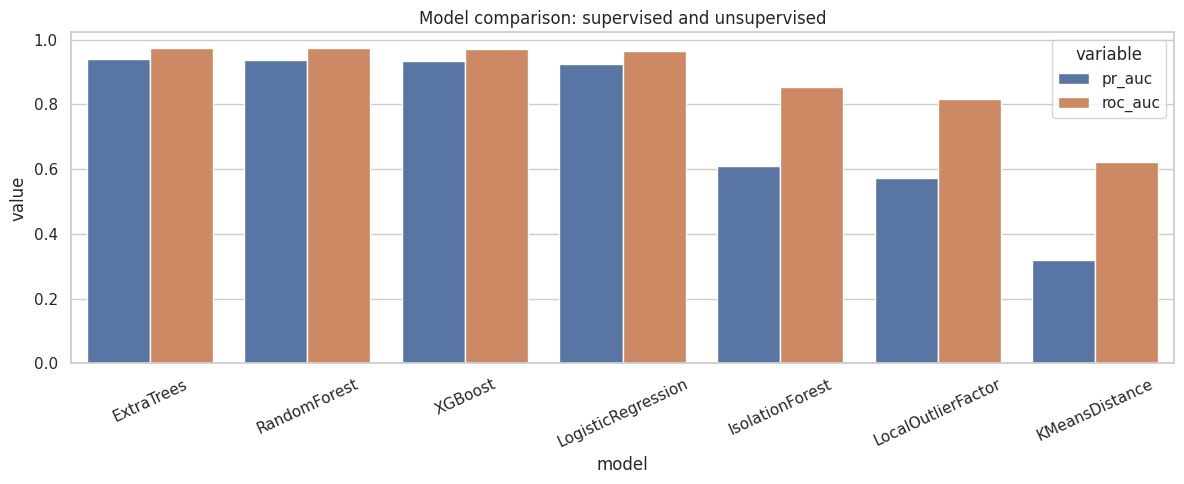

In [15]:
best_supervised_row = results_df.iloc[0].copy()
best_supervised_name = best_supervised_row["model"]

compare_df = pd.concat([
    results_df[["model", "roc_auc", "pr_auc", "recall", "precision", "f1", "specificity", "balanced_accuracy"]],
    unsup_results[["model", "roc_auc", "pr_auc", "recall", "precision", "f1", "specificity", "balanced_accuracy"]]
], ignore_index=True)

compare_df = compare_df.sort_values(["pr_auc", "roc_auc"], ascending=False)
display(compare_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=compare_df.melt(id_vars="model", value_vars=["pr_auc", "roc_auc"]),
            x="model", y="value", hue="variable")
plt.xticks(rotation=25)
plt.title("Model comparison: supervised and unsupervised")
plt.tight_layout()
plt.show()